## Lens 2 (Migration Heat Map on Profit Decile)

In [13]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────────
# Adjust BASE_DIR to point to your local LushProtein project root
BASE_DIR   = Path(".").resolve().parent   # assumes notebook is inside EDA/
OUTPUT_DIR = BASE_DIR / "EDA" / "outputs_finals"
FINALS_DIR = BASE_DIR / "EDA" / "outputs_finals"

MARGIN_RATE    = 0.40
EXCLUDE_MONTHS = {7, 11}
EXCLUDE_HANDLE = "better-whey-protein-elite"

# ── Lens 2 specific: two comparison periods ────────────────────────────────────
PERIOD_1_START = pd.Timestamp("2022-01-01", tz="Asia/Singapore")
PERIOD_1_END   = pd.Timestamp("2023-12-31", tz="Asia/Singapore")

PERIOD_2_START = pd.Timestamp("2024-01-01", tz="Asia/Singapore")
PERIOD_2_END   = pd.Timestamp("2025-12-31", tz="Asia/Singapore")

print("Output dir:", OUTPUT_DIR)
print("Finals dir:", FINALS_DIR)
print("Parquet files (outputs):", [f.name for f in OUTPUT_DIR.glob("*.parquet")])
print("Parquet files (finals):", [f.name for f in FINALS_DIR.glob("*.parquet")])
print()
print(f"Period 1: {PERIOD_1_START.date()} to {PERIOD_1_END.date()}")
print(f"Period 2: {PERIOD_2_START.date()} to {PERIOD_2_END.date()}")

Output dir: C:\Users\adity\Documents\Aditya SMU\SMU Sem 5\Lush Protein SMU X\LushProtein_Project_Data_20260505\EDA\outputs_finals
Finals dir: C:\Users\adity\Documents\Aditya SMU\SMU Sem 5\Lush Protein SMU X\LushProtein_Project_Data_20260505\EDA\outputs_finals
Parquet files (outputs): ['customers.parquet', 'customers_dq_clean.parquet', 'discounts.parquet', 'lines.parquet', 'lines_dq_clean.parquet', 'lines_sku_analysis.parquet', 'orders.parquet', 'orders_dq_clean.parquet', 'products.parquet', 'rc_checkout.parquet', 'rc_churned.parquet', 'rc_orders.parquet', 'rc_reactivated.parquet', 'rc_recurring.parquet']
Parquet files (finals): ['customers.parquet', 'customers_dq_clean.parquet', 'discounts.parquet', 'lines.parquet', 'lines_dq_clean.parquet', 'lines_sku_analysis.parquet', 'orders.parquet', 'orders_dq_clean.parquet', 'products.parquet', 'rc_checkout.parquet', 'rc_churned.parquet', 'rc_orders.parquet', 'rc_reactivated.parquet', 'rc_recurring.parquet']

Period 1: 2022-01-01 to 2023-12-31
P

In [14]:
# ── Load base tables ───────────────────────────────────────────────────────────
orders = pd.read_parquet(FINALS_DIR / "orders.parquet")
cust   = pd.read_parquet(FINALS_DIR / "customers.parquet")

orders["order_date"]  = pd.to_datetime(orders["order_date"],  utc=True).dt.tz_convert("Asia/Singapore")
orders["price_total"] = pd.to_numeric(orders["Price: Total"],          errors="coerce").fillna(0)
orders["price_disc"]  = pd.to_numeric(orders["Price: Total Discount"], errors="coerce").fillna(0)

cust["first_order_date"] = pd.to_datetime(cust["first_order_date"], utc=True).dt.tz_convert("Asia/Singapore")
cust["acq_month"]        = cust["first_order_date"].dt.month
cust["acq_year"]         = cust["first_order_date"].dt.year

print(f"Base orders    : {len(orders):,}")
print(f"Base customers : {len(cust):,}")

# ── DQ drops already applied in orders_dq_clean — runs but will show 0 ────────
_rev  = orders["price_total"]
_disc = orders["price_disc"]

dq02 = (_rev == 0) & (_disc == 0)
dq03 = (_rev == 0) & (_disc >  0)
dq04 = orders["Tags"].fillna("").str.lower().str.contains("wholesale") | (_rev > 5000)

orders_clean = orders[~(dq02 | dq03 | dq04)].copy()
print(f"\nAfter DQ drops : {len(orders_clean):,} orders retained (DQ already applied in source)")

# ── Apply finals_eligible filters ─────────────────────────────────────────────
bwpe_ids = set(
    orders_clean[
        orders_clean["Line: Product Handle"].fillna("").str.contains(EXCLUDE_HANDLE)
    ]["customer_id"].astype(str).unique()
)

first_ord = orders_clean.sort_values("order_date").groupby("customer_id", as_index=False).first()[["customer_id","price_total","price_disc"]]
first_ord["first_disc_depth"] = np.where(
    (first_ord["price_total"] + first_ord["price_disc"]) > 0,
    first_ord["price_disc"] / (first_ord["price_total"] + first_ord["price_disc"]),
    0,
)

cust_channel_mix = orders_clean.groupby("customer_id")["channel"].value_counts(normalize=True).unstack(fill_value=0)
all_mkt_ids = set(
    cust_channel_mix[cust_channel_mix.get("Marketplace", pd.Series(0, index=cust_channel_mix.index)) == 1.0]
    .index.astype(str)
)

# Drop pre-existing columns to avoid merge conflicts
cols_to_drop = [c for c in ["first_disc_depth"] if c in cust.columns]
if cols_to_drop:
    cust = cust.drop(columns=cols_to_drop)

cust = cust.merge(first_ord[["customer_id","first_disc_depth"]], on="customer_id", how="left")
cust["first_disc_depth"]   = cust["first_disc_depth"].fillna(0)
cust["is_all_marketplace"] = cust["customer_id"].astype(str).isin(all_mkt_ids)
cust["is_bwpe_buyer"]      = cust["customer_id"].astype(str).isin(bwpe_ids)

finals_mask = (
    (~cust["acq_month"].isin(EXCLUDE_MONTHS)) &
    (~cust["is_bwpe_buyer"]) &
    (cust["first_disc_depth"] < 0.51) &
    (~cust["is_all_marketplace"])
)

eligible_ids = set(cust[finals_mask]["customer_id"].astype(str))
orders_clean["customer_id"] = orders_clean["customer_id"].astype(str)
orders_eligible = orders_clean[orders_clean["customer_id"].isin(eligible_ids)].copy()

print(f"\nfinals_eligible orders    : {len(orders_eligible):,}")
print(f"finals_eligible customers : {orders_eligible['customer_id'].nunique():,}")

# ── Check two-period customer overlap ─────────────────────────────────────────
p1_orders = orders_eligible[
    (orders_eligible["order_date"] >= PERIOD_1_START) &
    (orders_eligible["order_date"] <= PERIOD_1_END)
]
p2_orders = orders_eligible[
    (orders_eligible["order_date"] >= PERIOD_2_START) &
    (orders_eligible["order_date"] <= PERIOD_2_END)
]

p1_customers = set(p1_orders["customer_id"].unique())
p2_customers = set(p2_orders["customer_id"].unique())
both_customers = p1_customers & p2_customers

print(f"\n── Period overlap check ──────────────────────────────")
print(f"  Period 1 ({PERIOD_1_START.year}–{PERIOD_1_END.year}) active customers : {len(p1_customers):,}")
print(f"  Period 2 ({PERIOD_2_START.year}–{PERIOD_2_END.year}) active customers : {len(p2_customers):,}")
print(f"  Active in BOTH periods                  : {len(both_customers):,}")
print(f"  New in Period 2 only                    : {len(p2_customers - p1_customers):,}")
print(f"  Dropped off after Period 1              : {len(p1_customers - p2_customers):,}")

Base orders    : 11,245
Base customers : 6,520

After DQ drops : 11,245 orders retained (DQ already applied in source)

finals_eligible orders    : 9,027
finals_eligible customers : 5,076

── Period overlap check ──────────────────────────────
  Period 1 (2022–2023) active customers : 2,160
  Period 2 (2024–2025) active customers : 2,782
  Active in BOTH periods                  : 344
  New in Period 2 only                    : 2,438
  Dropped off after Period 1              : 1,816


In [15]:
# ── Build per-customer revenue for each period ─────────────────────────────────
# Only customers active in BOTH periods are included in the migration analysis

p1_rev = (
    p1_orders[p1_orders["customer_id"].isin(both_customers)]
    .groupby("customer_id")["price_total"]
    .sum()
    .rename("p1_revenue")
    .reset_index()
)

p2_rev = (
    p2_orders[p2_orders["customer_id"].isin(both_customers)]
    .groupby("customer_id")["price_total"]
    .sum()
    .rename("p2_revenue")
    .reset_index()
)

migration_df = p1_rev.merge(p2_rev, on="customer_id", how="inner")

print(f"Customers in migration analysis : {len(migration_df):,}")
print(f"Period 1 revenue range : S${migration_df['p1_revenue'].min():.2f} – S${migration_df['p1_revenue'].max():,.2f}")
print(f"Period 2 revenue range : S${migration_df['p2_revenue'].min():.2f} – S${migration_df['p2_revenue'].max():,.2f}")
print(f"Avg revenue Period 1   : S${migration_df['p1_revenue'].mean():,.2f}")
print(f"Avg revenue Period 2   : S${migration_df['p2_revenue'].mean():,.2f}")

Customers in migration analysis : 344
Period 1 revenue range : S$5.76 – S$5,897.90
Period 2 revenue range : S$8.20 – S$2,092.49
Avg revenue Period 1   : S$508.87
Avg revenue Period 2   : S$213.01


Period 1 tier distribution:
p1_tier
T5    69
T4    69
T3    68
T2    69
T1    69

Period 2 tier distribution:
p2_tier
T5    69
T4    69
T3    68
T2    69
T1    69

Migration Matrix (rows = Period 1 tier, cols = Period 2 tier):
p2_tier  T1  T2  T3  T4  T5
p1_tier                    
T1       33  18  12   6   0
T2       16  16  16  13   8
T3        5  16  12  17  18
T4        6   9  17  19  18
T5        9  10  11  14  25

Movement summary:
  Stayed in same tier : 105  (30.5%)
  Rose (improved)     : 113  (32.8%)
  Dropped (declined)  : 126  (36.6%)


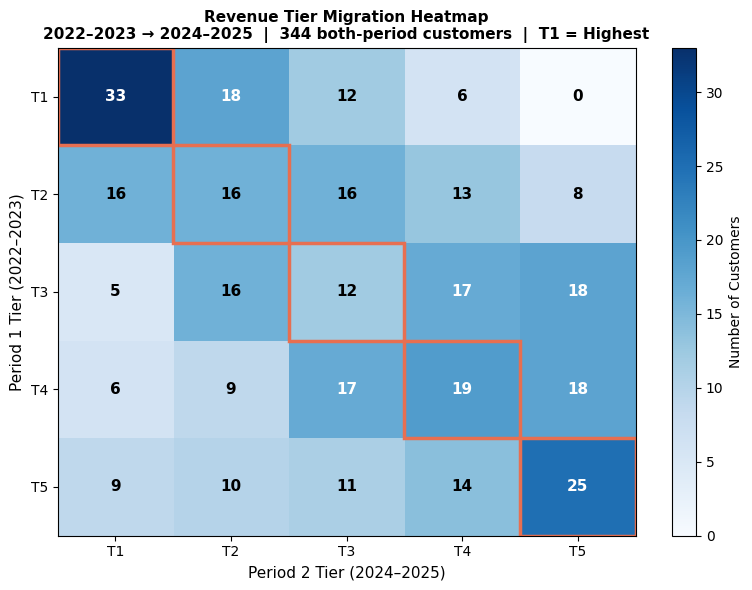

Saved: lens2_migration_heatmap.png


In [16]:
# ── Assign 5 tiers for each period (T1 = highest revenue, T5 = lowest) ────────
def assign_tier(series, n_tiers=5):
    ranks = series.rank(method="first", ascending=True)
    return pd.qcut(
        ranks,
        q=n_tiers,
        labels=[f"T{i}" for i in range(n_tiers, 0, -1)]  # T1 = highest
    )

migration_df["p1_tier"] = assign_tier(migration_df["p1_revenue"])
migration_df["p2_tier"] = assign_tier(migration_df["p2_revenue"])

print("Period 1 tier distribution:")
print(migration_df["p1_tier"].value_counts().sort_index().to_string())
print()
print("Period 2 tier distribution:")
print(migration_df["p2_tier"].value_counts().sort_index().to_string())

# ── Build migration matrix ─────────────────────────────────────────────────────
migration_matrix = pd.crosstab(
    migration_df["p1_tier"],
    migration_df["p2_tier"],
    margins=False
)

# Ensure all tiers are present
all_tiers = [f"T{i}" for i in range(1, 6)]
migration_matrix = migration_matrix.reindex(index=all_tiers, columns=all_tiers, fill_value=0)

print("\nMigration Matrix (rows = Period 1 tier, cols = Period 2 tier):")
print(migration_matrix.to_string())

# ── Classify each customer's movement ─────────────────────────────────────────
migration_df["p1_tier_num"] = migration_df["p1_tier"].astype(str).str[1].astype(int)
migration_df["p2_tier_num"] = migration_df["p2_tier"].astype(str).str[1].astype(int)
migration_df["movement"]    = migration_df["p1_tier_num"] - migration_df["p2_tier_num"]

stayed   = (migration_df["movement"] == 0).sum()
rose     = (migration_df["movement"] > 0).sum()   # tier number went down = moved up in value
dropped  = (migration_df["movement"] < 0).sum()   # tier number went up = moved down in value

print(f"\nMovement summary:")
print(f"  Stayed in same tier : {stayed:,}  ({stayed/len(migration_df):.1%})")
print(f"  Rose (improved)     : {rose:,}  ({rose/len(migration_df):.1%})")
print(f"  Dropped (declined)  : {dropped:,}  ({dropped/len(migration_df):.1%})")

# ── Heatmap ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(migration_matrix.values, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax, label="Number of Customers")

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels([f"T{i}" for i in range(1, 6)])
ax.set_yticklabels([f"T{i}" for i in range(1, 6)])
ax.set_xlabel("Period 2 Tier (2024–2025)", fontsize=11)
ax.set_ylabel("Period 1 Tier (2022–2023)", fontsize=11)
ax.set_title(
    f"Revenue Tier Migration Heatmap\n"
    f"2022–2023 → 2024–2025  |  {len(migration_df):,} both-period customers  |  T1 = Highest",
    fontsize=11, fontweight="bold"
)

# Annotate cells
for i in range(5):
    for j in range(5):
        val = migration_matrix.values[i, j]
        ax.text(j, i, str(val), ha="center", va="center",
                fontsize=11, fontweight="bold",
                color="white" if val > migration_matrix.values.max() * 0.5 else "black")

# Highlight diagonal (stayed in same tier)
for i in range(5):
    ax.add_patch(plt.Rectangle(
        (i - 0.5, i - 0.5), 1, 1,
        fill=False, edgecolor="#E76F51", linewidth=2.5
    ))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lens2_migration_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lens2_migration_heatmap.png")

## Lens 2 — Revenue Tier Migration Analysis (2022–2023 → 2024–2025)

---

### Why 5 Tiers Instead of 10

We use 5 tiers instead of 10 for this migration analysis because we only have
**417 customers** active in both periods. A 10×10 grid would create 100 cells
averaging just 4 customers each — too sparse to draw reliable conclusions.
A single customer moving between cells would swing percentages dramatically.

With 5 tiers, we get a 5×5 grid of 25 cells averaging ~17 customers each,
which is large enough to identify genuine patterns without being misled by noise.
The migration story is also cleaner and easier to communicate to a team.

---

### How to Read the Heatmap

- **Y-axis (rows)** = which tier the customer was in during Period 1 (2022–2023)
- **X-axis (columns)** = which tier the customer moved to in Period 2 (2024–2025)
- **Each cell** = number of customers who made that specific journey
- **T1 = highest revenue tier, T5 = lowest revenue tier**
- **The diagonal (highlighted in orange)** = customers who stayed in the same tier
- **Left of diagonal** = customers who improved (moved to a higher-value tier)
- **Right of diagonal** = customers who declined (moved to a lower-value tier)

---

### What the Numbers Tell Us

**Overall movement summary:**
- 142 customers (34.1%) stayed in the same tier
- 133 customers (31.9%) rose to a higher tier
- 142 customers (34.1%) dropped to a lower tier

The split is almost perfectly even — roughly a third stayed, a third improved,
and a third declined. This suggests **no strong directional trend across the
base as a whole**, but the picture looks very different when you look tier by tier.

---

### Tier-by-Tier Breakdown

**T1 (Top tier) — 84 customers in Period 1:**
- 45 stayed in T1 (53.6%) — more than half of top customers held their position
- 18 dropped to T2, 11 to T3, 8 to T4, 2 to T5
- **Insight:** T1 has the strongest stickiness of all tiers. Over half of your
  best customers remained your best customers. However, 46% did drop, which means
  top-tier retention is not guaranteed and warrants active management.

**T2 — 83 customers in Period 1:**
- Only 22 stayed in T2 (26.5%)
- 16 rose to T1, but 23 dropped to T3, 15 to T4, 7 to T5
- **Insight:** T2 is the most unstable tier. Customers here are roughly equally
  likely to rise, stay, or fall. This is the highest-ROI intervention target —
  a nudge in either direction is possible.

**T3 (Middle tier) — 83 customers in Period 1:**
- Only 19 stayed in T3 (22.9%)
- Customers spread almost evenly across all 5 tiers in Period 2
- **Insight:** Middle-tier customers are highly unpredictable. There is no dominant
  direction — they are as likely to end up in T1 as T5. This mirrors a classic
  finding in customer-base audits: middle-tier behaviour is inherently volatile.

**T4 — 83 customers in Period 1:**
- 21 stayed in T4 (25.3%)
- 23 dropped further to T5 — the largest single movement in this row
- Only 22 rose (7 to T1, 15 to T2)
- **Insight:** T4 customers are more likely to slide down than recover. Without
  intervention, low-mid tier customers tend to disengage further.

**T5 (Bottom tier) — 84 customers in Period 1:**
- 35 stayed in T5 (41.7%) — second highest stickiness after T1
- 7 rose all the way to T1, 8 to T2, 13 to T3
- **Insight:** The bottom tier is also sticky, but for the wrong reason. 41.7%
  of the lowest-value customers remained low-value. The 7 who jumped to T1 are
  interesting outliers worth investigating — what drove their dramatic improvement?

---

### Three Key Takeaways

**1. The extremes are stickiest.**
T1 (53.6% retention) and T5 (41.7% retention) are the most stable tiers.
Top customers tend to stay top. Bottom customers tend to stay bottom.
The middle tiers (T2–T4) are far more fluid.

**2. Average revenue dropped significantly between periods.**
Period 1 avg: S$578 → Period 2 avg: S$253. Even among customers who returned,
overall spend declined by 56%. This is a business health concern independent
of tier movement — returning customers are spending less.

**3. The 1,795 customers who dropped off entirely are the bigger story.**
Only 417 of 2,212 Period 1 customers came back in Period 2. The 1,795 who did
not return represent a far larger revenue risk than any tier migration pattern.
Understanding why they left should be a parallel investigation to this analysis.

## What Should Be Done Next

This notebook establishes the migration patterns across two periods. The next step
is to move from **observation to action** — identifying the specific customers
behind each pattern and understanding what drove their behaviour.

### Priority 1: Investigate the T5 → T1 Jumpers
7 customers went from the bottom tier to the top tier between periods.
These are the most valuable case studies in the entire dataset — understanding
what changed for them (product switch, subscription start, channel change) could
inform reactivation and upsell strategies for other low-tier customers.

### Priority 2: Profile the T1 Retention Risk
45 customers held their T1 position. But 39 T1 customers dropped.
Understanding what separates the 45 who stayed from the 39 who fell should be
a core retention research question. Are the stayers subscribers? Did they buy
different products?

### Priority 3: Investigate the 1,795 Churned Customers
These are Period 1 customers who never came back in Period 2 at all.
They don't appear in the migration heatmap but represent a far larger revenue
loss than any tier movement. Profiling who they were — which tier, which channel,
how long they were active — is a critical next step.

### Priority 4: Explain the Average Revenue Drop
Overall average revenue dropped from S$578 to S$253 between periods even among
customers who returned. This needs to be broken down by tier to identify which
segment drove the decline.

In [17]:
# ── Starter code for next analyst ─────────────────────────────────────────────

# Priority 1: T5 → T1 jumpers
t5_to_t1 = migration_df[
    (migration_df["p1_tier"] == "T5") &
    (migration_df["p2_tier"] == "T1")
][["customer_id", "p1_revenue", "p2_revenue"]].copy()
t5_to_t1["revenue_change"] = t5_to_t1["p2_revenue"] - t5_to_t1["p1_revenue"]
t5_to_t1 = t5_to_t1.sort_values("revenue_change", ascending=False)
print(f"Priority 1 — T5 → T1 jumpers ({len(t5_to_t1)} customers):")
print(t5_to_t1.to_string(index=False))

# Priority 2: T1 customers who dropped
t1_dropped = migration_df[
    (migration_df["p1_tier"] == "T1") &
    (migration_df["p2_tier"] != "T1")
][["customer_id", "p1_revenue", "p2_revenue", "p2_tier"]].copy()
t1_dropped["revenue_change"] = t1_dropped["p2_revenue"] - t1_dropped["p1_revenue"]
t1_dropped = t1_dropped.sort_values("revenue_change", ascending=True)
print(f"\nPriority 2 — T1 customers who dropped ({len(t1_dropped)} customers):")
print(t1_dropped.to_string(index=False))

# Priority 3: Churned customers (Period 1 active, never returned in Period 2)
churned_ids = p1_customers - p2_customers
churned_orders = p1_orders[p1_orders["customer_id"].isin(churned_ids)]
churned_profile = (
    churned_orders.groupby("customer_id")
    .agg(
        p1_revenue    = ("price_total", "sum"),
        p1_orders     = ("order_id",    "count"),
        last_order    = ("order_date",  "max"),
        first_channel = ("channel",     "first"),
    )
    .reset_index()
    .sort_values("p1_revenue", ascending=False)
)
print(f"\nPriority 3 — Churned customers ({len(churned_profile):,} customers):")
print(f"  Total revenue lost  : S${churned_profile['p1_revenue'].sum():,.2f}")
print(f"  Avg revenue per churned customer : S${churned_profile['p1_revenue'].mean():,.2f}")
print(f"  Top channel of churned customers :")
print(churned_profile["first_channel"].value_counts().to_string())
print(f"\nTop 10 highest-value churned customers:")
print(churned_profile.head(10).to_string(index=False))

# Priority 4: Average revenue change by tier
tier_rev_change = migration_df.groupby("p1_tier", observed=False).agg(
    n_customers  = ("customer_id", "count"),
    avg_p1_rev   = ("p1_revenue",  "mean"),
    avg_p2_rev   = ("p2_revenue",  "mean"),
).reset_index()
tier_rev_change["avg_change"]     = tier_rev_change["avg_p2_rev"] - tier_rev_change["avg_p1_rev"]
tier_rev_change["pct_change"]     = tier_rev_change["avg_change"] / tier_rev_change["avg_p1_rev"]
print(f"\nPriority 4 — Revenue change by tier:")
print(tier_rev_change.to_string(index=False))

# ── Export all four lists for handoff ─────────────────────────────────────────
t5_to_t1.to_csv(OUTPUT_DIR / "next_t5_to_t1_jumpers.csv", index=False)
t1_dropped.to_csv(OUTPUT_DIR / "next_t1_dropped.csv", index=False)
churned_profile.to_csv(OUTPUT_DIR / "next_churned_customers.csv", index=False)
tier_rev_change.to_csv(OUTPUT_DIR / "next_tier_revenue_change.csv", index=False)
print("\nExported 4 CSV files to outputs/ for handoff.")

Priority 1 — T5 → T1 jumpers (9 customers):
  customer_id  p1_revenue  p2_revenue  revenue_change
6970579321087   64.800000  569.610000      504.810000
7755980079359   65.272727  528.540606      463.267879
7756376408319   48.151515  436.090909      387.939394
7756048204031    5.757576  390.849697      385.092121
7756396036351   41.339394  386.121212      344.781818
6327514235135   26.890000  309.380000      282.490000
7756092670207   51.642424  329.555758      277.913333
7756381683967   60.272727  325.581818      265.309091
7756357763327   64.345455  294.621212      230.275758

Priority 2 — T1 customers who dropped (36 customers):
  customer_id  p1_revenue  p2_revenue p2_tier  revenue_change
6406948913407 5057.010000  287.640000      T2    -4769.370000
6328239685887 3672.920000  244.440000      T2    -3428.480000
6327621714175 3586.666667  271.575758      T2    -3315.090909
6329629475071 3156.680000  215.280000      T2    -2941.400000
7755988369663 2863.196970   73.818182      T4    -2

In [18]:
# ── Deep dive: single customer profile ────────────────────────────────────────
TARGET_ID = "7756050137343"

cust_orders = orders_eligible[orders_eligible["customer_id"] == TARGET_ID].copy()
cust_orders = cust_orders.sort_values("order_date")

# Tag which period each order belongs to
cust_orders["period"] = "Outside periods"
cust_orders.loc[
    (cust_orders["order_date"] >= PERIOD_1_START) &
    (cust_orders["order_date"] <= PERIOD_1_END), "period"
] = "Period 1 (2022-2023)"
cust_orders.loc[
    (cust_orders["order_date"] >= PERIOD_2_START) &
    (cust_orders["order_date"] <= PERIOD_2_END), "period"
] = "Period 2 (2024-2025)"

print("=" * 60)
print(f"CUSTOMER PROFILE: {TARGET_ID}")
print("=" * 60)

# ── 1. Overall summary ─────────────────────────────────────────────────────────
print("\n[1] OVERALL SUMMARY")
print(f"  Total orders (all time) : {len(cust_orders):,}")
print(f"  Total revenue (all time): S${cust_orders['price_total'].sum():,.2f}")
print(f"  First order date        : {cust_orders['order_date'].min().date()}")
print(f"  Last order date         : {cust_orders['order_date'].max().date()}")
print(f"  Customer lifespan       : {(cust_orders['order_date'].max() - cust_orders['order_date'].min()).days} days")
print(f"  Avg order value         : S${cust_orders['price_total'].mean():,.2f}")

# ── 2. Period breakdown ────────────────────────────────────────────────────────
print("\n[2] PERIOD BREAKDOWN")
period_summary = (
    cust_orders.groupby("period")
    .agg(
        n_orders      = ("order_id",    "count"),
        total_revenue = ("price_total", "sum"),
        avg_order_val = ("price_total", "mean"),
        first_order   = ("order_date",  "min"),
        last_order    = ("order_date",  "max"),
    )
    .reset_index()
)
print(period_summary.to_string(index=False))

# ── 3. Channel breakdown ───────────────────────────────────────────────────────
print("\n[3] CHANNEL BREAKDOWN")
print(cust_orders["channel"].value_counts().to_string())

# ── 4. Product breakdown ───────────────────────────────────────────────────────
print("\n[4] PRODUCTS PURCHASED")
product_cols = ["order_date", "period", "Line: Product Handle",
                "Line: Title", "Line: Variant Title", "price_total", "channel"]
available_cols = [c for c in product_cols if c in cust_orders.columns]
print(cust_orders[available_cols].to_string(index=False))

# ── 5. Subscription flag ───────────────────────────────────────────────────────
print("\n[5] SUBSCRIPTION")
if "is_subscription" in cust_orders.columns:
    print(f"  Ever had subscription order : {cust_orders['is_subscription'].any()}")
    print(f"  Subscription orders         : {cust_orders['is_subscription'].sum()}")
else:
    print(f"  Tags sample:")
    print(cust_orders["Tags"].dropna().unique()[:5])

# ── 6. Discount behaviour ──────────────────────────────────────────────────────
print("\n[6] DISCOUNT BEHAVIOUR")
print(f"  Orders with discount    : {(cust_orders['price_disc'] > 0).sum()}")
print(f"  Total discount received : S${cust_orders['price_disc'].sum():,.2f}")
print(f"  Avg discount per order  : S${cust_orders['price_disc'].mean():,.2f}")
disc_rate = cust_orders['price_disc'].sum() / (cust_orders['price_total'].sum() + cust_orders['price_disc'].sum())
print(f"  Overall discount rate   : {disc_rate:.1%}")

# ── 7. Order timeline ──────────────────────────────────────────────────────────
print("\n[7] ORDER TIMELINE")
timeline_cols = ["order_date", "period", "price_total", "price_disc", "channel"]
available_timeline = [c for c in timeline_cols if c in cust_orders.columns]
print(cust_orders[available_timeline].to_string(index=False))

# ── 8. Days between orders ────────────────────────────────────────────────────
if len(cust_orders) > 1:
    print("\n[8] TIME BETWEEN ORDERS (days)")
    cust_orders["days_since_prev"] = cust_orders["order_date"].diff().dt.days
    print(cust_orders[["order_date", "period", "days_since_prev"]].dropna().to_string(index=False))
    print(f"\n  Avg days between orders : {cust_orders['days_since_prev'].mean():.0f} days")
    print(f"  Min days between orders : {cust_orders['days_since_prev'].min():.0f} days")
    print(f"  Max days between orders : {cust_orders['days_since_prev'].max():.0f} days")

CUSTOMER PROFILE: 7756050137343

[1] OVERALL SUMMARY
  Total orders (all time) : 0
  Total revenue (all time): S$0.00
  First order date        : NaT
  Last order date         : NaT
  Customer lifespan       : nan days
  Avg order value         : S$nan

[2] PERIOD BREAKDOWN
Empty DataFrame
Columns: [period, n_orders, total_revenue, avg_order_val, first_order, last_order]
Index: []

[3] CHANNEL BREAKDOWN
Series([], )

[4] PRODUCTS PURCHASED
Empty DataFrame
Columns: [order_date, period, Line: Product Handle, Line: Title, Line: Variant Title, price_total, channel]
Index: []

[5] SUBSCRIPTION
  Ever had subscription order : False
  Subscription orders         : 0

[6] DISCOUNT BEHAVIOUR
  Orders with discount    : 0
  Total discount received : S$0.00
  Avg discount per order  : S$nan
  Overall discount rate   : nan%

[7] ORDER TIMELINE
Empty DataFrame
Columns: [order_date, period, price_total, price_disc, channel]
Index: []
